In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append("../KAIR")

%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import torch

from utils import utils_image, utils_model, utils_sisr

In [2]:
def imshow(ax, img, **kwargs):
    ax.imshow(np.clip(img, 0, 1), **kwargs)

## Load base image here.
You may check for other color images in the specified directory, or may chose another image of your liking.

In [3]:
img_path = "../KAIR/testsets/set5/butterfly.bmp"
img_L = utils_image.imread_uint(img_path, n_channels=3)
img_L = utils_image.uint2single(img_L)

### Lets downsample the image.

In [4]:
img_LQ = utils_sisr.bicubic_degradation(img_L, sf=4)

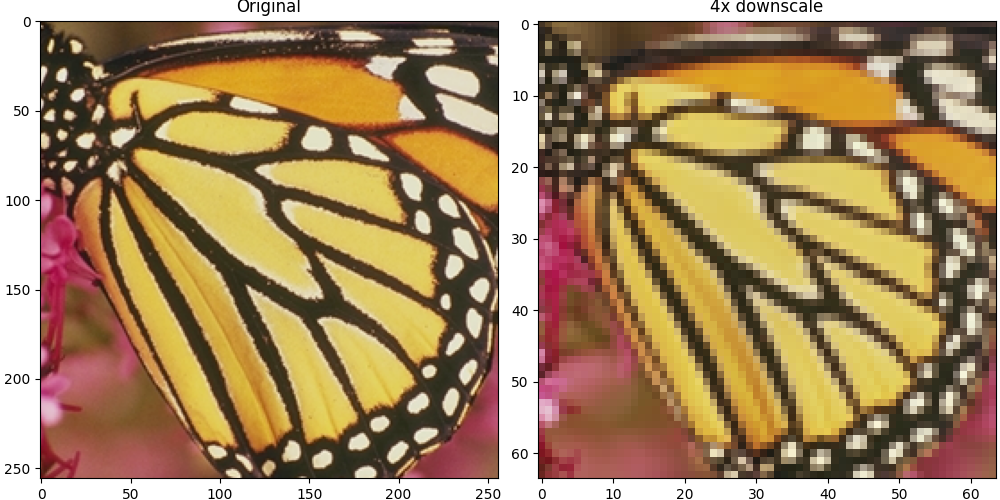

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
imshow(ax[0], img_L)
ax[0].set_title("Original")

imshow(ax[1], img_LQ)
ax[1].set_title("4x downscale");

Define our base metrics

In [10]:
def psnr(x, y):
    return utils_image.calculate_psnr(
        utils_image.single2uint(x),
        utils_image.single2uint(y), border=0)
    
def ssim(x, y):
    return utils_image.calculate_ssim(
        utils_image.single2uint(x),
        utils_image.single2uint(y), border=0)

## 4x Upscaling with MSRResNet
Fixed upscaling level.
You may switch to a psnr-trained model below.

In [11]:
from models.network_msrresnet import MSRResNet1
n_channels = 3
nb = 16
model_path = "../KAIR/model_zoo/msrresnet_x4_gan.pth"
# model_path = "../KAIR/model_zoo/msrresnet_x4_psnr.pth"

msr = MSRResNet1(in_nc=n_channels, out_nc=n_channels, nc=64, nb=nb, upscale=4)
msr.load_state_dict(torch.load(model_path), strict=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
msr = msr.eval().to(device)

def upscale_msr(x):
    x = utils_image.single2tensor4(x).to(device)
    with torch.no_grad():
        upscaled = msr(x)
    upscaled = utils_image.tensor2single(upscaled)
    return np.clip(upscaled, 0, 1)

In [12]:
bicubic = utils_image.imresize_np(img_LQ, 4) # 4x resampling through bicubic
upscaled_msr     = upscale_msr(img_LQ)       # 4x Restoration through MSR
supersampled_msr = upscale_msr(img_L)        # 4x SuperResolution through MSR

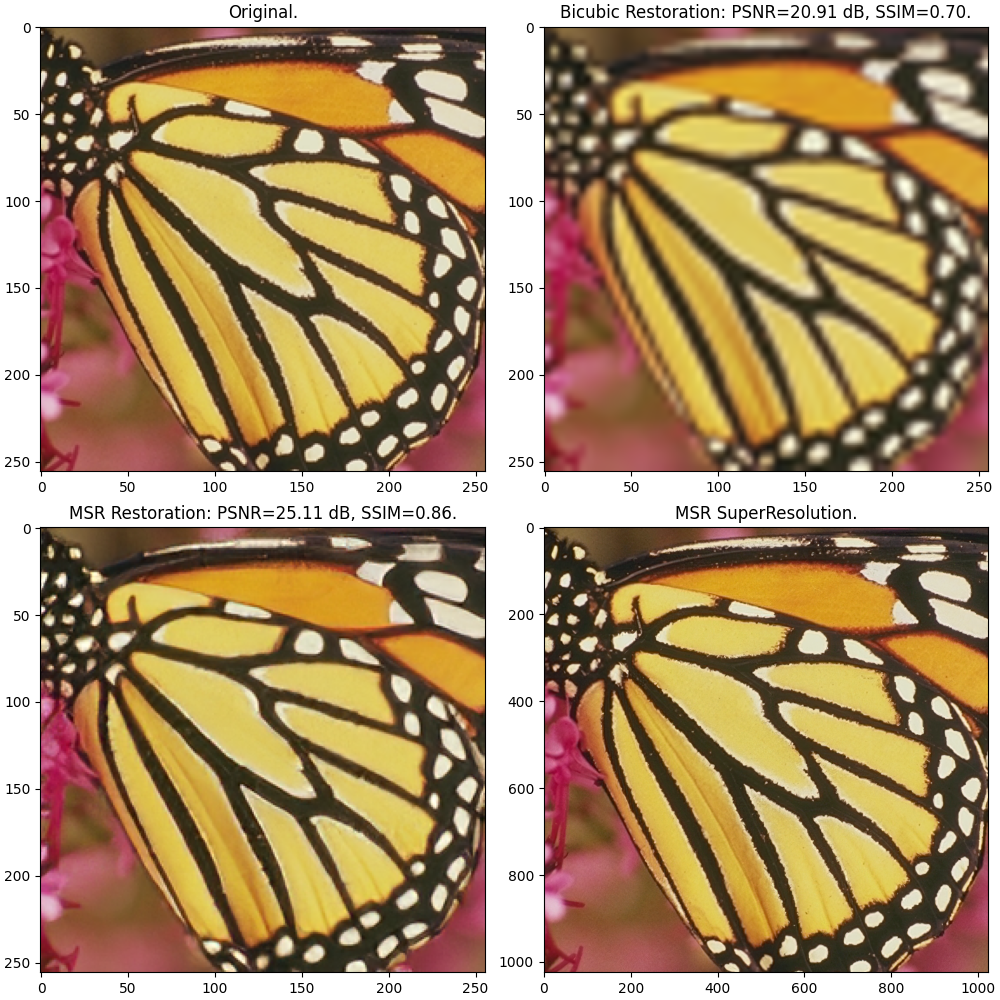

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)

imshow(ax[0, 0], img_L)
ax[0, 0].set_title("Original.")
imshow(ax[0, 1], bicubic)
ax[0, 1].set_title(f"Bicubic Restoration: PSNR={psnr(img_L, bicubic):.2f} dB, SSIM={ssim(img_L, bicubic):.2f}.");
imshow(ax[1, 0], upscaled_msr)
ax[1, 0].set_title(f"MSR Restoration: PSNR={psnr(img_L, upscaled_msr):.2f} dB, SSIM={ssim(img_L, upscaled_msr):.2f}.");
imshow(ax[1, 1], supersampled_msr)
ax[1, 1].set_title("MSR SuperResolution.");

## 4x Upscaling with SwinIR
There are other upscaling levels available.
You may switch to different SR tasks, below, check out the KAIR/model_zoo/swinir/ directory

In [15]:
from types import SimpleNamespace
from main_test_swinir import define_model, setup

args = SimpleNamespace(
    task="lightweight_sr",
    model_path="../KAIR/model_zoo/swinir/002_lightweightSR_DIV2K_s64w8_SwinIR-S_x4.pth",
    scale=4,
    training_patch_size=64,
)
swinir = define_model(args)
swinir = swinir.eval().to(device)

def upscale_swinir(x):
    x = utils_image.single2tensor4(x).to(device)
    with torch.no_grad():
        upscaled = swinir(x)
    upscaled = utils_image.tensor2single(upscaled)
    return np.clip(upscaled, 0, 1)

In [16]:
bicubic = utils_image.imresize_np(img_LQ, 4) # 4x resampling through bicubic
upscaled_swinir     = upscale_swinir(img_LQ) # 4x Restoration
supersampled_swinir = upscale_swinir(img_L)  # 4x SuperResolution

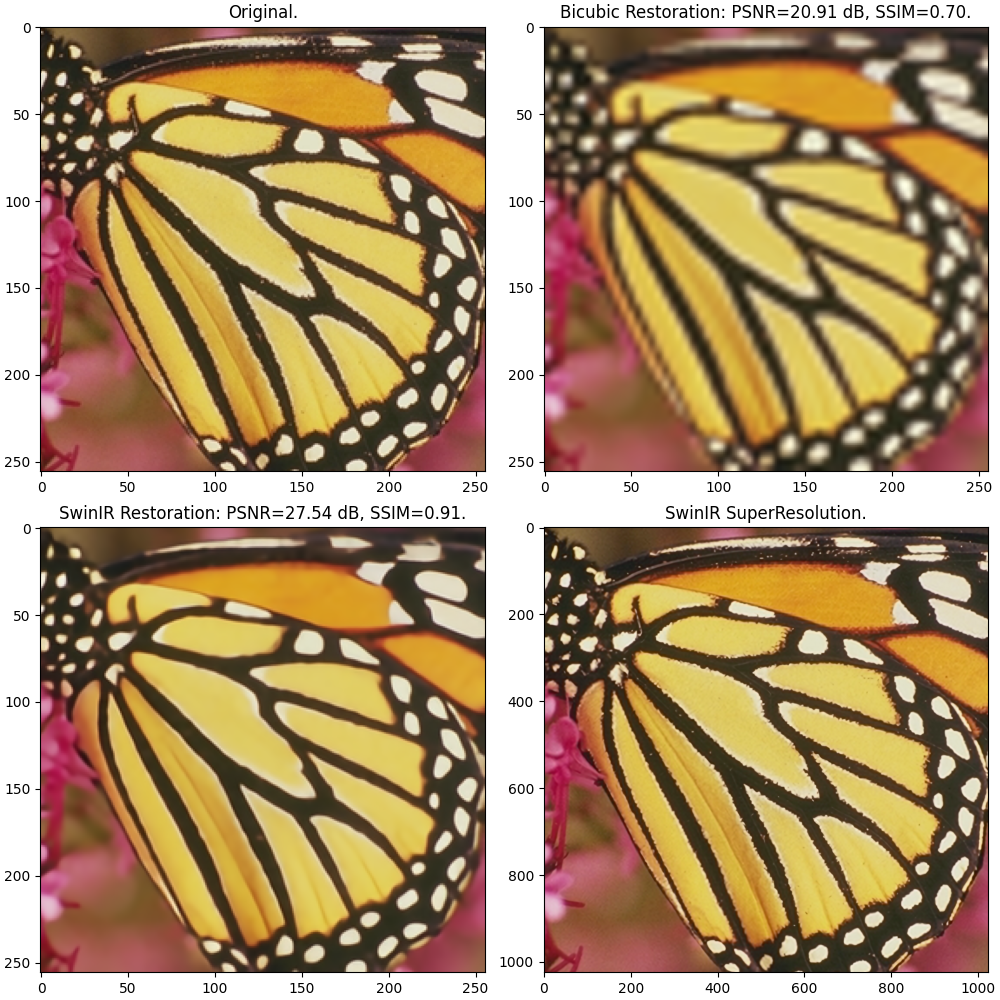

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)

imshow(ax[0, 0], img_L)
ax[0, 0].set_title("Original.")
imshow(ax[0, 1], bicubic)
ax[0, 1].set_title(f"Bicubic Restoration: PSNR={psnr(img_L, bicubic):.2f} dB, SSIM={ssim(img_L, bicubic):.2f}.");
imshow(ax[1, 0], upscaled_swinir)
ax[1, 0].set_title(f"SwinIR Restoration: PSNR={psnr(img_L, upscaled_swinir):.2f} dB, SSIM={ssim(img_L, upscaled_swinir):.2f}.");
imshow(ax[1, 1], supersampled_swinir)
ax[1, 1].set_title("SwinIR SuperResolution.");